<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Data%20Preparation/SMOTE_Oversampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [202]:
#Generate an unblanced dataset
from sklearn.datasets import make_classification
import numpy as np

# Create a synthetic dataset
X, y = make_classification(
n_samples=1000,
n_features=2,
n_informative=2,
n_redundant=0, n_repeated=0, n_classes=3,
n_clusters_per_class=1,
weights=[0.01, 0.05, 0.94],
class_sep=0.8, random_state=0
)

print(f"Shape of data (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

# Calculate and print the actual percentage of examples for each class
class_counts = np.bincount(y)
total_samples = len(y)
class_percentages = np.round(class_counts / total_samples * 100, 2)

for i, percentage in enumerate(class_percentages):
    print(f"Class {i}: {percentage}% of examples")

Shape of data (X): (1000, 2)
Shape of labels (y): (1000,)
Class 0: 1.3% of examples
Class 1: 5.5% of examples
Class 2: 93.2% of examples


In [203]:
import pandas as pd

# Combine features (X) and labels (y) into a single DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(X.shape[1])])
df['target'] = y

# Display the first 5 rows of the DataFrame
display(df.head())

,feature_1,feature_2,target
0,-0.734722,1.073192,2
1,-1.931123,0.377214,2
2,-1.384845,1.052459,2
3,-1.628224,0.618430,2
4,1.624233,0.583935,2


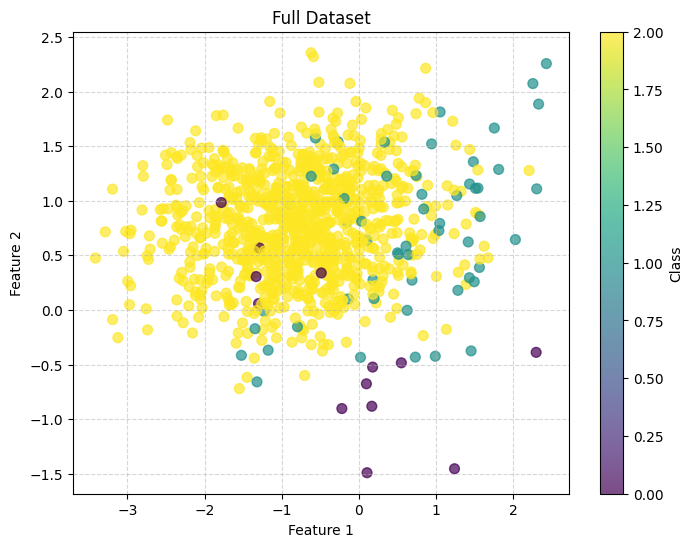

In [204]:
import matplotlib.pyplot as plt

# Create a scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Full Dataset')
plt.colorbar(label='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [205]:
# Split Training and Test Sets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Separate features (X) and target (y)
X_df = df.drop('target', axis=1)
y_df = df['target']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.3, random_state=42, stratify=y_df)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (700, 2)
Testing set shape: (300, 2)


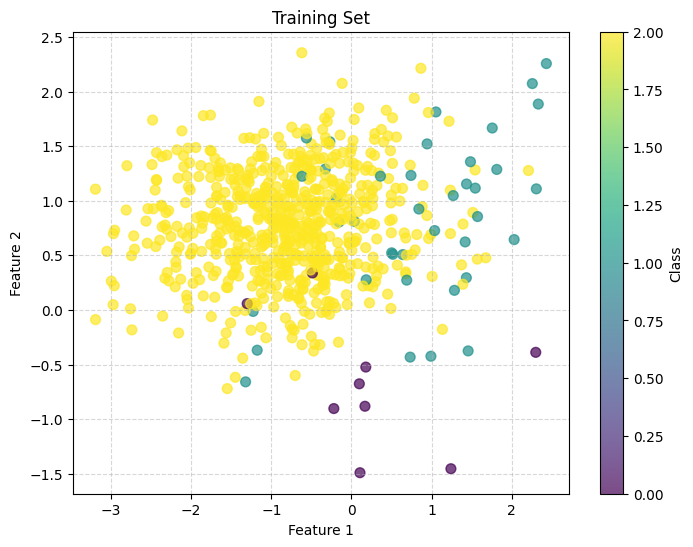

In [206]:
import matplotlib.pyplot as plt

# Create a scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Set')
plt.colorbar(label='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [207]:
# Initialize and train a Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1', 'Class 2'])

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         4
     Class 1       0.14      0.12      0.13        16
     Class 2       0.94      0.96      0.95       280

    accuracy                           0.90       300
   macro avg       0.36      0.36      0.36       300
weighted avg       0.89      0.90      0.89       300



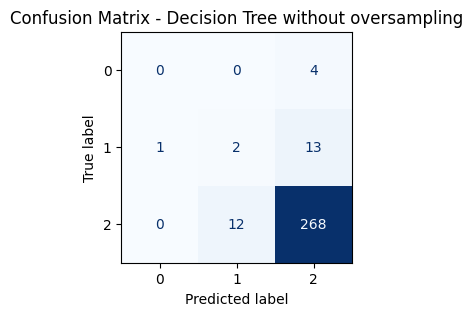

In [208]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Decision Tree without oversampling')
plt.show()

In [209]:
#Oversample with SMOTE
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of original training data: {X_train.shape}")
print(f"Shape of resampled training data: {X_train_resampled.shape}")

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Shape of original training data: (700, 2)
Shape of resampled training data: (1956, 2)

Class distribution after SMOTE:
target
2    652
1    652
0    652
Name: count, dtype: int64


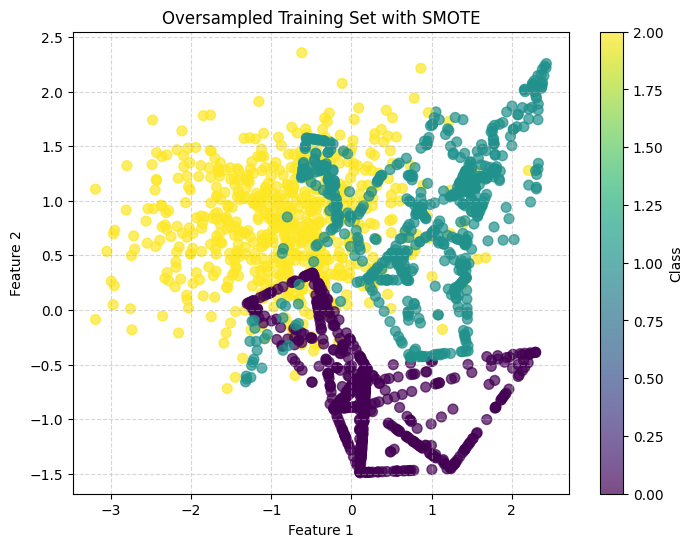

In [210]:
import matplotlib.pyplot as plt

# Create a scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_resampled.iloc[:, 0], X_train_resampled.iloc[:, 1], c=y_train_resampled, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Oversampled Training Set with SMOTE')
plt.colorbar(label='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Accuracy (with SMOTE): 0.7567

Classification Report (with SMOTE):
              precision    recall  f1-score   support

     Class 0       0.06      0.25      0.10         4
     Class 1       0.16      0.56      0.25        16
     Class 2       0.96      0.78      0.86       280

    accuracy                           0.76       300
   macro avg       0.39      0.53      0.40       300
weighted avg       0.91      0.76      0.81       300



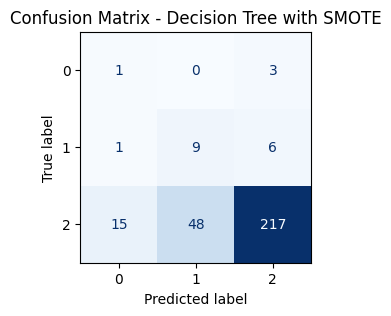

In [211]:
# Retrain the Decision Tree Classifier with the SMOTE-resampled data
dtc_resampled = DecisionTreeClassifier(random_state=42)
dtc_resampled.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original (unresampled) test set
y_pred_resampled = dtc_resampled.predict(X_test)

# Evaluate the model with resampled training
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
report_resampled = classification_report(y_test, y_pred_resampled, target_names=['Class 0', 'Class 1', 'Class 2'])

print(f"Accuracy (with SMOTE): {accuracy_resampled:.4f}")
print("\nClassification Report (with SMOTE):")
print(report_resampled)

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_resampled, cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Decision Tree with SMOTE')
plt.show()

In [212]:
#Oversample with Borderline SMOTE - 'borderline-1'
from imblearn.over_sampling import BorderlineSMOTE

# Apply BorderlineSMOTE to the training data
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of original training data: {X_train.shape}")
print(f"Shape of resampled training data: {X_train_resampled.shape}")

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Shape of original training data: (700, 2)
Shape of resampled training data: (1956, 2)

Class distribution after SMOTE:
target
2    652
1    652
0    652
Name: count, dtype: int64


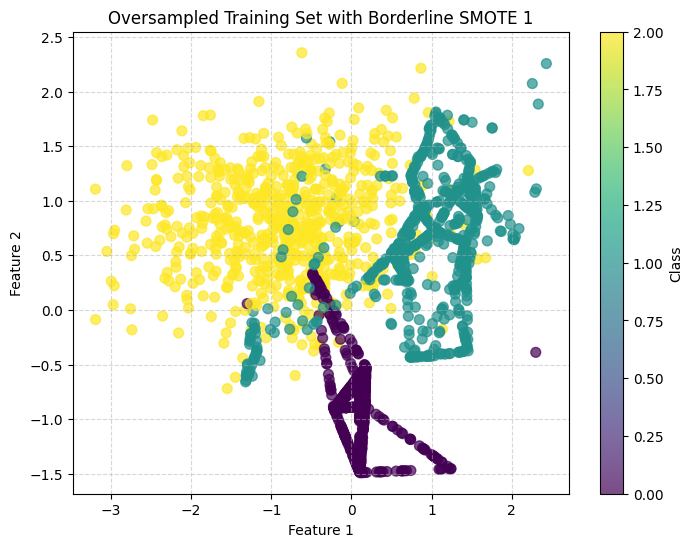

In [213]:
import matplotlib.pyplot as plt

# Create a scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_resampled.iloc[:, 0], X_train_resampled.iloc[:, 1], c=y_train_resampled, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Oversampled Training Set with Borderline SMOTE 1')
plt.colorbar(label='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Accuracy (with Borderline SMOTE 1): 0.8233

Classification Report (with Borderline SMOTE 1):
              precision    recall  f1-score   support

     Class 0       0.20      0.25      0.22         4
     Class 1       0.16      0.44      0.23        16
     Class 2       0.96      0.85      0.90       280

    accuracy                           0.82       300
   macro avg       0.44      0.51      0.45       300
weighted avg       0.90      0.82      0.86       300



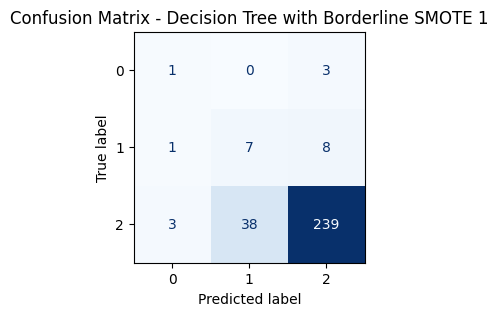

In [214]:
# Retrain the Decision Tree Classifier with the Borderline SMOTE-resampled data
dtc_resampled = DecisionTreeClassifier(random_state=42)
dtc_resampled.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original (unresampled) test set
y_pred_resampled = dtc_resampled.predict(X_test)

# Evaluate the model with resampled training
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
report_resampled = classification_report(y_test, y_pred_resampled, target_names=['Class 0', 'Class 1', 'Class 2'])

print(f"Accuracy (with Borderline SMOTE 1): {accuracy_resampled:.4f}")
print("\nClassification Report (with Borderline SMOTE 1):")
print(report_resampled)

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_resampled, cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Decision Tree with Borderline SMOTE 1')
plt.show()

In [215]:
#Oversample with Borderline SMOTE - 'borderline-2'

from imblearn.over_sampling import BorderlineSMOTE

# Apply BorderlineSMOTE to the training data
smote = BorderlineSMOTE(random_state=42, kind='borderline-2')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of original training data: {X_train.shape}")
print(f"Shape of resampled training data: {X_train_resampled.shape}")

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Shape of original training data: (700, 2)
Shape of resampled training data: (1956, 2)

Class distribution after SMOTE:
target
2    652
1    652
0    652
Name: count, dtype: int64


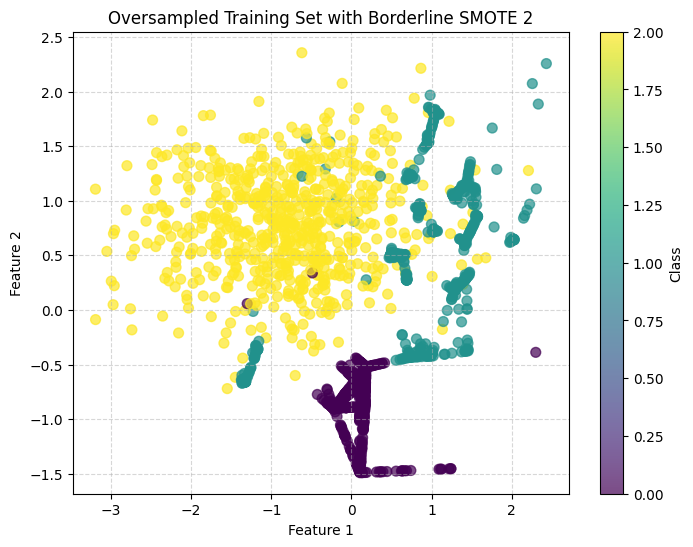

In [216]:
import matplotlib.pyplot as plt

# Create a scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_resampled.iloc[:, 0], X_train_resampled.iloc[:, 1], c=y_train_resampled, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Oversampled Training Set with Borderline SMOTE 2')
plt.colorbar(label='Class')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Accuracy (with SMOTE): 0.9000

Classification Report (with SMOTE):
              precision    recall  f1-score   support

     Class 0       0.50      0.25      0.33         4
     Class 1       0.28      0.44      0.34        16
     Class 2       0.96      0.94      0.95       280

    accuracy                           0.90       300
   macro avg       0.58      0.54      0.54       300
weighted avg       0.92      0.90      0.91       300



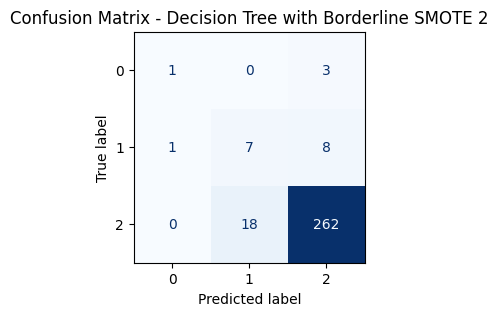

In [217]:
# Retrain the Decision Tree Classifier with the SMOTE-resampled data
dtc_resampled = DecisionTreeClassifier(random_state=42)
dtc_resampled.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original (unresampled) test set
y_pred_resampled = dtc_resampled.predict(X_test)

# Evaluate the model with resampled training
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
report_resampled = classification_report(y_test, y_pred_resampled, target_names=['Class 0', 'Class 1', 'Class 2'])

print(f"Accuracy (with SMOTE): {accuracy_resampled:.4f}")
print("\nClassification Report (with SMOTE):")
print(report_resampled)

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_resampled, cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - Decision Tree with Borderline SMOTE 2')
plt.show()